# DDPM Example Usage

This script walks through the full workflow:
setup → train → save/load → generate → plot.
Make sure the `ddpm/` package folder is in the same directory (or on your PYTHONPATH).

cd "C:\Users\lodik\Documents\programming\diffusion-models-project-main"

git status
git add ddpm example_usage_ddpm.ipynb changes.txt .gitignore
git status
git commit -m "Update DDPM project"
git push

In [19]:
# --- Setup repo in Colab ---
%cd /content

import os
import sys

repo_path = "/content/ddpm-project-lodi"

if not os.path.exists(repo_path):
    !git clone https://github.com/LodiHendrikKamman/ddpm-project-lodi.git

%cd /content/ddpm-project-lodi
!git pull
!pip install -r requirements.txt

# Make sure Python can find the repo/package
if repo_path not in sys.path:
    sys.path.append(repo_path)

/content
/content/ddpm-project-lodi
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 17.58 KiB | 1.26 MiB/s, done.
From https://github.com/LodiHendrikKamman/ddpm-project-lodi
   1f2d211..3fe8f1c  main       -> origin/main
Updating 1f2d211..3fe8f1c
Fast-forward
 changes.txt              |   1 +
 ddpm-project-lodi        |   1 +
 ddpm/train.py            |   6 +--
 example_usage_ddpm.ipynb | 130 ++++++++++++++++++-----------------------------
 4 files changed, 54 insertions(+), 84 deletions(-)
 create mode 160000 ddpm-project-lodi


In [20]:
# --- Imports ---
import torch

from ddpm import NoiseScheduler, UNet, train, find_lr, generate_image, noisy_image
from ddpm.dataset import load_mnist, get_noisy_loaders
from ddpm.utils import load_unet, channel_list, model_name, path_name
from ddpm.viz import plot_generated
import random
import numpy as np

# --- Expected behaviouring ---
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports worked!")

Using device: cuda
Imports worked!


## 1. Noise scheduler and data

The scheduler defines the beta schedule and handles the forward noising process.
T=1000 steps, linearly spaced betas from 1e-4 to 0.02 (Ho et al. defaults).

In [21]:
scheduler = NoiseScheduler(T=1000, beta_start=1e-4, beta_end=0.02).to(device)

train_set, test_set = load_mnist()
train_loader, test_loader = get_noisy_loaders(train_set, test_set, scheduler, batch_size=32)

### Training on a single digit

Pass a filter function to get_noisy_loaders_filtered to restrict the dataset.
Here we train on zeros only, but any (dataset -> Subset) function works.

In [22]:
from ddpm.dataset import get_noisy_loaders_filtered, zeros_only

train_loader_zeros, test_loader_zeros = get_noisy_loaders_filtered(
    train_set, test_set, scheduler, filter_fn=zeros_only, batch_size=32
)

unet_zeros = UNet(
    channels=channel_list(64),
    convs_per_level=2,
    num_heads_att=4,
    time_emb_dim=128,
    time_emb_base_dim=32,
).to(device)

train_losses, test_losses = train(
    unet_zeros,
    train_loader_zeros,
    test_loader_zeros,
    epochs=50,
    lr=1e-3,
    save_path='zeros_only_time.pkl',
    use_time=False,
)

x = generate_image(unet_zeros, scheduler, n_images=8)
plot_generated(x, ncol=4)

TypeError: train() got an unexpected keyword argument 'use_time'

## 2. Build a UNet

`channels` sets the feature map depth at each encoder level.
The decoder mirrors this automatically.
`convs_per_level` is how many conv layers per resolution block. look at the documentation of UNet for a bit more detail (or ask Elias). The structure of the unet is basically taken from ronneberger et al., 2015 (the original unet paper, see also illustration in lilian wengs blog).

A reasonable small model to start with:

In [ ]:
channels = channel_list(64)   # -> [64, 128, 256]
cpl = 2                       # convs per level

unet = UNet(channels=channels, convs_per_level=cpl).to(device)
print(f"Model: {model_name(64, cpl)}")
print(f"Parameters: {sum(p.numel() for p in unet.parameters()):,}")

Model: C0_64_convs_2
Parameters: 2,315,009


## 3. Find a learning rate

Runs the LR range test and returns the suggested LR.
Multiply by ~0.5 for a conservative starting point.

LR finder:   0%|          | 0/100 [00:00<?, ?it/s]

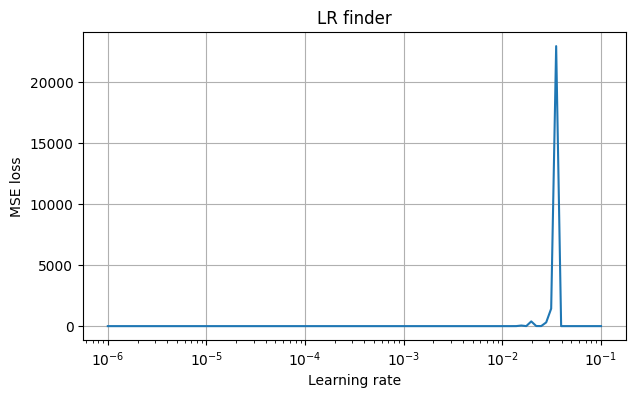

Suggested LR: 2.26e-06 → using 1.13e-06


In [ ]:
suggested_lr = find_lr(unet_zeros, train_loader_zeros, start_lr=1e-6, end_lr=1e-1, num_iter=100)
lr = suggested_lr * 0.5
print(f"Suggested LR: {suggested_lr:.2e} → using {lr:.2e}")

In [ ]:
5/0

ZeroDivisionError: division by zero

## 4. Train

`train()` returns the loss histories and saves the best checkpoint automatically.
Early stopping kicks in after `early_stopping_patience` epochs without improvement.

In [ ]:
save_path = path_name(64, cpl)   # e.g. "base_C0_64_convs_2.pkl"

train_losses, test_losses = train(
    unet, train_loader, test_loader,
    epochs=50,
    lr=lr,
    weight_decay=1e-6,
    early_stopping_patience=10,
    save_path=save_path,
)

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

train:   0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

Plot the loss curves manually (training doesn't do this anymore):

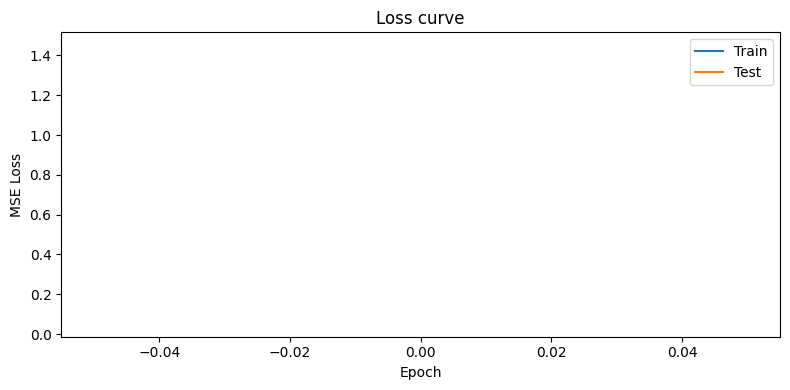

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(test_losses,  label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss curve')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Save and load

`train()` already saves the best checkpoint to `save_path`.
To reload later (e.g. after restarting the kernel):

In [ ]:
unet_loaded = load_unet(save_path, channels=channels, convs_per_level=cpl)
# unet_loaded is already in eval mode and on `device`

## 6. Generate images

`generate_image` runs the full reverse diffusion chain (T steps).
Returns a tensor of shape (n_images, 1, 28, 28).
`stochasticity=1.0` is full DDPM sampling; 0.0 is deterministic.

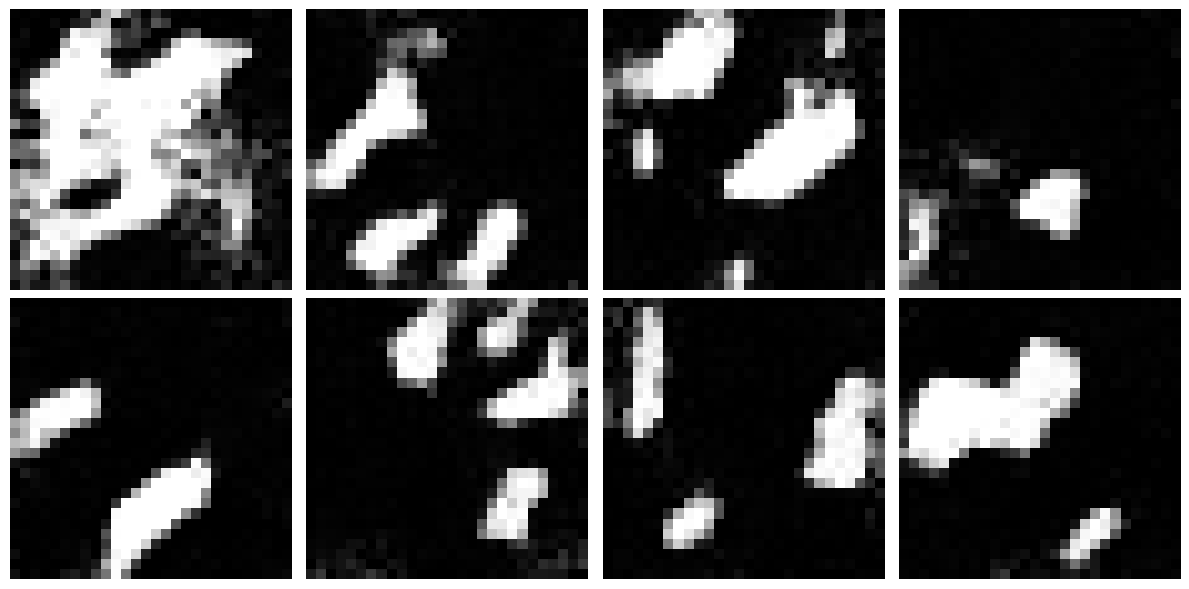

In [ ]:
x = generate_image(unet_loaded, scheduler, stochasticity=1.0, n_images=8)
plot_generated(x, ncol=4)

### Intermediates

You can inspect the denoising trajectory by returning intermediate steps.

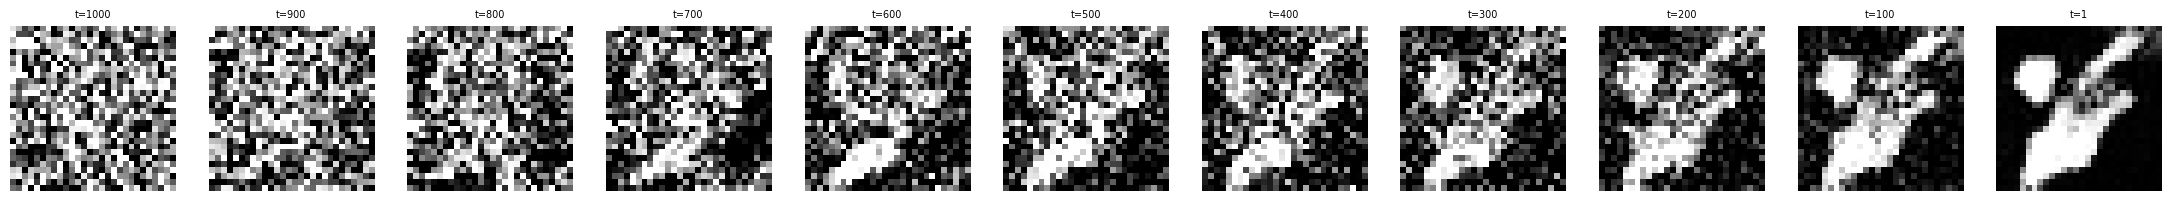

In [ ]:
x_final, intermediates = generate_image(
    unet_loaded, scheduler, stochasticity=1.0, n_images=1, return_intermediates=True
)

# Plot every 100th step
fig, axes = plt.subplots(1, 11, figsize=(22, 2))
steps_to_show = list(range(0, 1000, 100)) + [999]
for ax, idx in zip(axes, steps_to_show):
    img = intermediates[idx].squeeze()
    if img.min() < 0:
        img = (img + 1) / 2
    ax.imshow(img.clamp(0, 1), cmap='gray')
    ax.set_title(f't={1000 - idx}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()